In [61]:
# Change dir
import os
os.chdir('/Users/seandickson/JohnsHopkinsScripts/CreatingAIEnabledSystems/ironclad-Sean090900/ironclad')

In [62]:
import numpy as np
from PIL import Image
from modules.extraction.preprocessing import Preprocessing
from modules.extraction.embedding import Embedding
from modules.retrieval.index.bruteforce import FaissBruteForce
from modules.retrieval.index.hnsw import FaissHNSW
from modules.retrieval.index.lsh import FaissLSH
from modules.retrieval.search import FaissSearch

print('DONE')

DONE


In [88]:
# Sort gallery into buckets of #images present

m_i_dict = {}
probe_path = 'storage/multi_image_gallery'
for image_set in os.listdir(probe_path):
    if image_set != 'sample_gallery.py':
        images = os.listdir(probe_path + '/' + image_set)
        m_i_dict[image_set] = len(images)



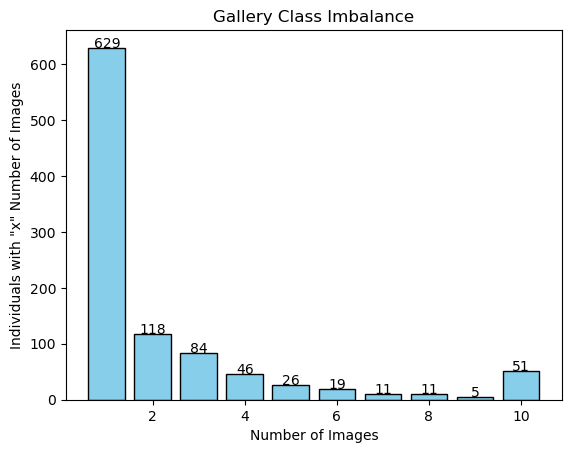

In [89]:
import matplotlib.pyplot as plt
from collections import Counter

# Count how many keys per integer value
counts = Counter(m_i_dict.values())

# Separate keys (the integers) and counts
x = list(counts.keys())
y = list(counts.values())

# Create bar plot
plt.bar(x, y, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Number of Images')
plt.ylabel('Individuals with "x" Number of Images')
plt.title('Gallery Class Imbalance')

# Optional: show exact counts above bars
for i, v in enumerate(y):
    plt.text(x[i], v + 0.1, str(v), ha='center')

plt.savefig("storage/charts/gallery_class_imbalance.png", dpi=300, bbox_inches='tight')
plt.show()

In [86]:
# Bring the total number of images down to the same level for each bucket
import shutil

dataset_path = 'storage/multi_image_gallery'

for i in range(10):
    bucket = i + 1
    total = int(40 / bucket)
    for image_set in os.listdir(dataset_path):
        if image_set != 'sample_gallery.py':
            images = os.listdir(dataset_path + '/' + image_set)
            if len(images) == bucket:
                # Add individual to new sampled dataset
                dataset_images_path = f'storage/multi_image_gallery/{image_set}'
                dataset_images_destination_path = f'storage/task4_sampled_gallery/{image_set}'
                shutil.copytree(dataset_images_path, dataset_images_destination_path)
                # Add cooresponding probe image to new dataset
                probe_path = f'storage/probe/{image_set}'
                probe_destination_path = f'storage/task4_sampled_probe/{image_set}'
                shutil.copytree(probe_path, probe_destination_path)
                total -= 1
        if total == 0:
            break



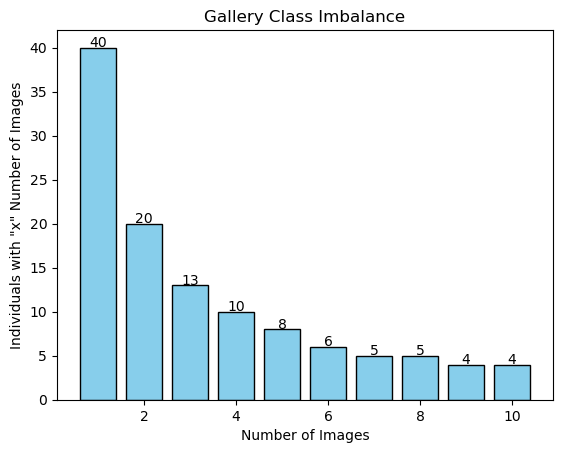

In [90]:
### CHECK SAMPLED DATASET CLASS BALANCE ###

import matplotlib.pyplot as plt
from collections import Counter

m_i_dict = {}
probe_path = 'storage/task4_sampled_gallery'
for image_set in os.listdir(probe_path):
    if image_set != 'sample_gallery.py':
        images = os.listdir(probe_path + '/' + image_set)
        m_i_dict[image_set] = len(images)

# Count how many keys per integer value
counts = Counter(m_i_dict.values())

# Separate keys (the integers) and counts
x = list(counts.keys())
y = list(counts.values())

# Create bar plot
plt.bar(x, y, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Number of Images')
plt.ylabel('Individuals with "x" Number of Images')
plt.title('Gallery Class Imbalance')

# Optional: show exact counts above bars
for i, v in enumerate(y):
    plt.text(x[i], v + 0.1, str(v), ha='center')

plt.savefig("storage/charts/sampled_gallery_balance.png", dpi=300, bbox_inches='tight')
plt.show()


In [107]:
# For each bucket, calculate mAP@K for vggface2 AND casia-webface models

## List of designed parameters: 
N = 1
MODEL = 'casia-webface'             # Variable
INDEX = 'bruteforce'                # Constant
SIMILARITY_MEASURE = 'euclidean'    # Constant

# Object Initialization
preprocessor = Preprocessing()
model = Embedding(MODEL)
index = FaissBruteForce.load(f'storage/embeddings/{MODEL}/faiss_{INDEX}_{MODEL}_task4_sampled_index.pkl')
# index = FaissHNSW.load(f'storage/embeddings/{MODEL}/faiss_{INDEX}_{MODEL}_index.pkl')
# index = FaissLSH.load(f'storage/embeddings/{MODEL}/faiss_{INDEX}_{MODEL}_index.pkl')
search = FaissSearch(index, metric=SIMILARITY_MEASURE)


In [108]:
def calculate_avg_prec_at_k(goal, meta_results):
    # Parse name
    name = goal.split('_')[0] + '_' + goal.split('_')[1]
    # Calculate
    correct = 0
    sum_precisions = 0
    for i in range(len(meta_results)):
        result = meta_results[i]
        if name in result:
            correct += 1
            sum_precisions += correct / (i + 1)
    # Return value
    if correct == 0:
        return 0
    return sum_precisions / correct

In [109]:
# Get all individuals for given bucket

key = {i+1:[] for i in range(10)}
for indiv in os.listdir('storage/task4_sampled_gallery'):
    length = len(os.listdir(f'storage/task4_sampled_gallery/{indiv}'))
    key[length].append(indiv)

key

{1: ['Paul_McNulty',
  'Phil_Mickelson',
  'Jim_Edmonds',
  'Jose_Theodore',
  'Tony_Curtis',
  'Gro_Harlem_Brundtland',
  'Angela_Lansbury',
  'Cathy_Freeman',
  'Christine_Ebersole',
  'Alison_Lohman',
  'Duane_Lee_Chapman',
  'Iban_Mayo',
  'Eric_Rosser',
  'Beth_Jones',
  'Chris_Byrd',
  'Charlotte_Rampling',
  'Grady_Irvin_Jr',
  'Prince_Edward',
  'Lyle_Vanclief',
  'Eric_Hinske',
  'Harbhajan_Singh',
  'Jia_Qinglin',
  'Carlos_Ghosn',
  'Bill_Sizemore',
  'John_McEnroe',
  'Carolina_Moraes',
  'Isaiah_Washington',
  'Penelope_Ann_Miller',
  'Luke_Walton',
  'Darren_Clarke',
  'Jean-Marc_de_La_Sabliere',
  'Kurt_Busch',
  'Felix_Mantilla',
  'David_Myers',
  'Aung_San_Suu_Kyi',
  'Chakib_Khelil',
  'Ricky_Barnes',
  'Jane_Pauley',
  'Bernardo_Segura',
  'Chen_Liang_Yu'],
 2: ['Mary-Kate_Olsen',
  'Lynne_Cheney',
  'Mathias_Reichhold',
  'Gianna_Angelopoulos-Daskalaki',
  'Lou_Piniella',
  'Stanley_McChrystal',
  'Intisar_Ajouri',
  'Daniel_Day-Lewis',
  'Bill_Callahan',
  'Abdull

In [110]:

scores = {}
for num, individuals in key.items():
    print(f'Bucket: {num}')
    sum = 0
    count = 0
    for individual in individuals:
        for image_name in os.listdir(f'storage/task4_sampled_probe/{individual}'):
            path = f'storage/task4_sampled_probe/{individual}/{image_name}'
            image = Image.open(path)
            processed_tensor = preprocessor.process(image)
            query_vector = model.encode(processed_tensor)
            distances, indices, meta_results = search.search(query_vector, k=N)
            avg_prec_at_k = calculate_avg_prec_at_k(str(image_name), meta_results)
            sum += avg_prec_at_k
            count += 1

    avg = sum / count
    print(f'Mean Average Precision @ k [BUCKET {num}]: {avg}')
    scores[num] = avg

Bucket: 1
Mean Average Precision @ k [BUCKET 1]: 0.1
Bucket: 2
Mean Average Precision @ k [BUCKET 2]: 0.1
Bucket: 3
Mean Average Precision @ k [BUCKET 3]: 0.15384615384615385
Bucket: 4
Mean Average Precision @ k [BUCKET 4]: 0.2
Bucket: 5
Mean Average Precision @ k [BUCKET 5]: 0.125
Bucket: 6
Mean Average Precision @ k [BUCKET 6]: 0.16666666666666666
Bucket: 7
Mean Average Precision @ k [BUCKET 7]: 0.4
Bucket: 8
Mean Average Precision @ k [BUCKET 8]: 0.0
Bucket: 9
Mean Average Precision @ k [BUCKET 9]: 0.25
Bucket: 10
Mean Average Precision @ k [BUCKET 10]: 0.5


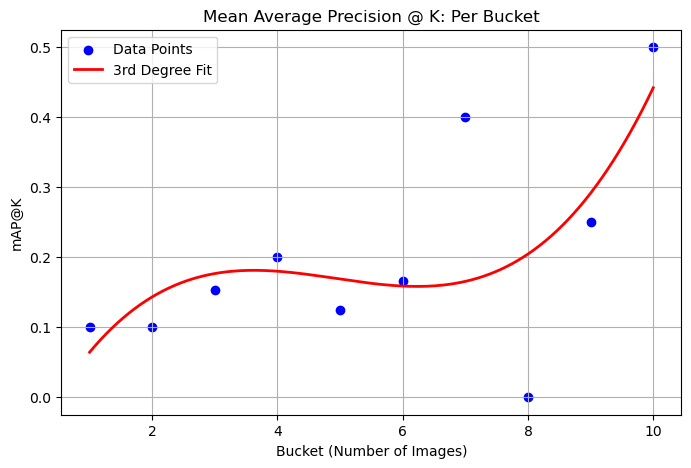

In [111]:
x = np.array(list(scores.keys()))
y = np.array(list(scores.values()))

# Fit a 3rd-degree polynomial
degree = 3
coeffs = np.polyfit(x, y, degree)
curve = np.poly1d(coeffs)

# Generate smooth x-values for plotting the curve
x_smooth = np.linspace(min(x), max(x), 200)
y_smooth = curve(x_smooth)

# Plot data and smooth curve
plt.figure(figsize=(8,5))
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x_smooth, y_smooth, 'r-', linewidth=2, label=f'{degree}rd Degree Fit')
plt.title('Mean Average Precision @ K: Per Bucket')
plt.xlabel('Bucket (Number of Images)')
plt.ylabel('mAP@K')
plt.legend()
plt.grid(True)

plt.savefig("storage/charts/casia-webface_mAP@K_per_bucket.png", dpi=300, bbox_inches='tight')
plt.show()